<a href="https://colab.research.google.com/github/hopefulmonstersucla/Structural-Bias-in-Mass-Action-Consumer-Resource-Models/blob/main/Epidemiology_Mass_Action.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange


In [ ]:
# Cell 2: Mount Google Drive and check file
from google.colab import drive
drive.mount('/content/drive')

# Optionally, check your directory
!ls "/content/drive/My Drive/Hopeful Monsters/Projects/Mass Action 2025/Datasets/Epidemiology"


Mounted at /content/drive
 EpiData_20251118_IHME-GBD_2023_DATA-fa649981-1.csv
'Epidemiology Mass Action.ipynb'
 global_cause_slopes.pdf
 global_cause_slopes_pt.pdf
 global_log10q_epidemiology_plot.pdf
 global_log10R_epidemiology_plot.pdf
 global_log10R_pt_epidemiology_plot.pdf
 global_log10z_epidemiology_plot.pdf
 logq_illness_panel.pdf
 logR_cause_panel_pt.pdf
 logR_illness_panel.pdf
 logz_cause_panel_pt.pdf
 merged_epidata_popdata_2023_prefixed.csv
 Popdata_20251118_IHME-GBD_2023_DATA-e3c86f01.csv
 z_histogram_epidemiology.pdf


In [ ]:
# Cell 3: Set file paths and load and preview data
epi_path = '/content/drive/My Drive/Hopeful Monsters/Projects/Mass Action 2025/Datasets/Epidemiology/EpiData_20251118_IHME-GBD_2023_DATA-fa649981-1.csv'
pop_path = '/content/drive/My Drive/Hopeful Monsters/Projects/Mass Action 2025/Datasets/Epidemiology/Popdata_20251118_IHME-GBD_2023_DATA-e3c86f01.csv'

epidata = pd.read_csv(epi_path)
popdata = pd.read_csv(pop_path)

print("Epidemiology data preview:")
print(epidata.head())

print("\nPopulation data preview:")
print(popdata.head())

Epidemiology data preview:
   measure_id measure_name  location_id location_name  sex_id sex_name  \
0           1       Deaths          148       Morocco       3     Both   
1           1       Deaths          148       Morocco       3     Both   
2           1       Deaths          148       Morocco       3     Both   
3           1       Deaths          148       Morocco       3     Both   
4           1       Deaths          148       Morocco       3     Both   

   age_id  age_name  cause_id    cause_name  metric_id metric_name  year  \
0      22  All ages       297  Tuberculosis          1      Number  2023   
1      22  All ages       297  Tuberculosis          2     Percent  2023   
2      22  All ages       297  Tuberculosis          3        Rate  2023   
3      22  All ages       298      HIV/AIDS          1      Number  2023   
4      22  All ages       298      HIV/AIDS          2     Percent  2023   

           val        upper       lower  
0  1430.216306  2781.147354  

In [ ]:
# Merge and keep both location_name columns by renaming before merge

# Filter for year 2023
epidata_2023 = epidata[epidata['year'] == 2023].copy()
popdata_2023 = popdata[popdata['year'] == 2023].copy()

# Prefix columns (except merge key)
epidata_2023_pref = epidata_2023.add_prefix('epi_')
popdata_2023_pref = popdata_2023.add_prefix('pop_')

# Un-prefix the merge key for correct joining
epidata_2023_pref = epidata_2023_pref.rename(columns={'epi_location_id': 'location_id'})
popdata_2023_pref = popdata_2023_pref.rename(columns={'pop_location_id': 'location_id'})

# (Optional: harmonize Turkey's naming before merging)
popdata_2023_pref['pop_location_name'] = popdata_2023_pref['pop_location_name'].replace('Türkiye', 'Turkey')

# Merge
merged = pd.merge(
    epidata_2023_pref,
    popdata_2023_pref[['location_id', 'pop_location_name', 'pop_val']],
    on='location_id',
    how='left'
)

# Check name harmony
name_match = (merged['epi_location_name'] == merged['pop_location_name']).mean()
print(f"Percent of rows with matching location_name: {name_match*100:.1f}%")
mismatches = merged[merged['epi_location_name'] != merged['pop_location_name']]
unique_mismatches = mismatches[['location_id', 'epi_location_name', 'pop_location_name']].drop_duplicates()
print(unique_mismatches)


# Drop non–human-to-human / mixed-route causes
drop_causes = [
    'Diarrheal diseases',
    'Typhoid and paratyphoid',
    'Invasive Non-typhoidal Salmonella (iNTS)',
    'Encephalitis',
    'Meningitis',
    'Tetanus'
    'Other intestinal infectious diseases',
]

merged = merged[~merged['epi_cause_name'].isin(drop_causes)]

# Save merged DataFrame
merged.to_csv('/content/drive/My Drive/Hopeful Monsters/Projects/Mass Action 2025/Datasets/Epidemiology/merged_epidata_popdata_2023_prefixed.csv', index=False)

# (Optional) Show head and column names
print(merged.head())
print(merged.columns.tolist())

Percent of rows with matching location_name: 99.0%
      location_id epi_location_name           pop_location_name
3590          155           Türkiye                      Turkey
4628            8            Taiwan  Taiwan (Province of China)
   epi_measure_id epi_measure_name  location_id epi_location_name  epi_sex_id  \
0               1           Deaths          148           Morocco           3   
1               1           Deaths          148           Morocco           3   
2               1           Deaths          148           Morocco           3   
3               1           Deaths          148           Morocco           3   
4               1           Deaths          148           Morocco           3   

  epi_sex_name  epi_age_id epi_age_name  epi_cause_id epi_cause_name  \
0         Both          22     All ages           297   Tuberculosis   
1         Both          22     All ages           297   Tuberculosis   
2         Both          22     All ages           297 

In [ ]:
# Identify object (text) columns
text_cols = merged.select_dtypes(include=['object']).columns

# Print unique values for each text column
for col in text_cols:
    unique_vals = merged[col].unique()
    print(f"Column: {col}")
    print(f"Number of unique values: {len(unique_vals)}")
    print(f"Sample unique values: {unique_vals[:10]}")
    print("="*40)

# Identify numeric columns
numeric_cols = merged.select_dtypes(include=['number']).columns

# Show summary statistics for numeric columns
for col in numeric_cols:
    median = merged[col].median()
    min_val = merged[col].min()
    max_val = merged[col].max()
    print(f"Column: {col}")
    print(f"Median: {median:.3f}")
    print(f"Min: {min_val:.3f}")
    print(f"Max: {max_val:.3f}")
    print("="*40)

Column: epi_measure_name
Number of unique values: 3
Sample unique values: ['Deaths' 'Prevalence' 'Incidence']
Column: epi_location_name
Number of unique values: 204
Sample unique values: ['Morocco' 'Russian Federation' 'Mali' 'Finland' 'Fiji' 'Samoa'
 'Solomon Islands' 'Mexico' 'Nicaragua' 'Andorra']
Column: epi_sex_name
Number of unique values: 1
Sample unique values: ['Both']
Column: epi_age_name
Number of unique values: 1
Sample unique values: ['All ages']
Column: epi_cause_name
Number of unique values: 12
Sample unique values: ['Tuberculosis' 'HIV/AIDS' 'Other intestinal infectious diseases'
 'Lower respiratory infections' 'Diphtheria' 'Pertussis' 'Tetanus'
 'Measles' 'Varicella and herpes zoster' 'COVID-19']
Column: epi_metric_name
Number of unique values: 3
Sample unique values: ['Number' 'Percent' 'Rate']
Column: pop_location_name
Number of unique values: 204
Sample unique values: ['Morocco' 'Russian Federation' 'Mali' 'Finland' 'Fiji' 'Samoa'
 'Solomon Islands' 'Mexico' 'Nicara

In [ ]:
# Cell 4: Define Variables and Filter

# Pivot to make each epi measure its own column
pivoted = merged.pivot_table(
    index=['location_id', 'epi_location_name', 'epi_cause_name', 'pop_location_name', 'pop_val'],
    columns='epi_measure_name',
    values='epi_val'
).reset_index()
pivoted.columns.name = None

# Rename for clarity
pivoted = pivoted.rename(columns={'Incidence': 'R', 'Prevalence': 'P', 'pop_val': 'N'})

# Define variables
R = pivoted['R']        # Incidence (rate of new infections)
N = pivoted['N']        # Population
P = pivoted['P']        # Prevalence (standing infection)

# (Optional) Filter for positive, non-missing values
mask = R.notna() & N.notna() & P.notna() & (R > 0) & (N > 0) & (P > 0)

# You can now use R, N, P with exactly the same logic as your viral workflow
# For example:
x = np.log10(N[mask].values * P[mask].values)   # corresponding to N * P
y_R = np.log10(R[mask].values)                  # Incidence axis
y_P = np.log10(P[mask].values)                  # Prevalence axis

# Examine the pivoted DataFrame
print("Pivoted DataFrame head:")
print(pivoted.head(10))

print("\nPivoted column names:")
print(pivoted.columns.tolist())

print("\nDescriptive stats for R, N, P (Incidence, Population, Prevalence):")
print(pivoted[['R', 'N', 'P']].describe())

for col in ['R', 'N', 'P']:
    min_val = pivoted[col].min()
    max_val = pivoted[col].max()
    print(f"{col}: min = {min_val:.3g}, max = {max_val:.3g}")




Pivoted DataFrame head:
   location_id epi_location_name  \
0            6             China   
1            6             China   
2            6             China   
3            6             China   
4            6             China   
5            6             China   
6            6             China   
7            6             China   
8            6             China   
9            6             China   

                                  epi_cause_name pop_location_name  \
0                                       COVID-19             China   
1                                     Diphtheria             China   
2                                       HIV/AIDS             China   
3                   Lower respiratory infections             China   
4                                        Measles             China   
5           Other intestinal infectious diseases             China   
6                                      Pertussis             China   
7  Sexually transmi

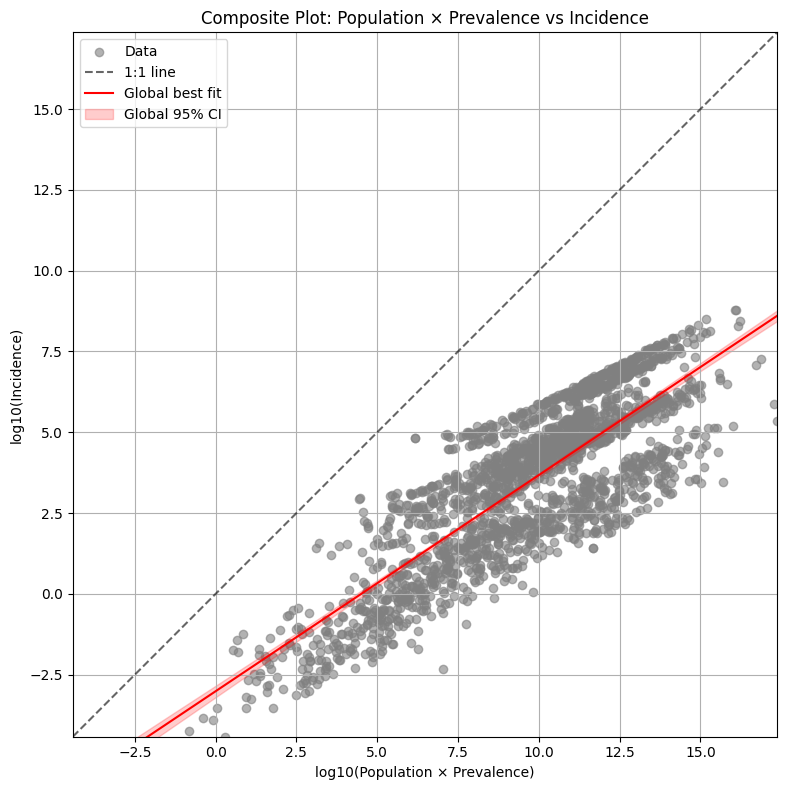

Global best fit slope: 0.6686
Global 95% bootstrap CI for slope: [0.6508, 0.6880]
Global bootstrap R2 mean: 0.6813 (95% CI: 0.6571, 0.7046)


In [ ]:
# Cell 5: Plot log10(R) and Ouput Stats

# R = incidence (rate), N = population, P = prevalence
mask = R.notna() & N.notna() & P.notna() & (R > 0) & (N > 0) & (P > 0)
x = np.log10(N[mask].values * P[mask].values)  # log10(sorry it is the y-axis.pop * prev)
y_R = np.log10(R[mask].values)                 # log10(incidence)

plt.figure(figsize=(8,8))
plt.scatter(x, y_R, alpha=0.6, label='Data', color='grey')
lims = [min(min(x), min(y_R)), max(max(x), max(y_R))]
plt.plot(lims, lims, 'k--', alpha=0.6, label='1:1 line')
plt.xlim(lims)
plt.ylim(lims)

# Fit line and bootstrap
slope_R, intercept_R = np.polyfit(x, y_R, 1)
n_bootstrap = 1000
slopes_R = []
intercepts_R = []
r2_R = []
for _ in range(n_bootstrap):
    idx = np.random.randint(0, len(x), len(x))
    x_sample = x[idx]
    y_sample = y_R[idx]
    s, b = np.polyfit(x_sample, y_sample, 1)
    slopes_R.append(s)
    intercepts_R.append(b)
    y_pred = s * x_sample + b
    ss_res = np.sum((y_sample - y_pred)**2)
    ss_tot = np.sum((y_sample - np.mean(y_sample))**2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
    r2_R.append(r2)
x_pred = np.linspace(lims[0], lims[1], 100)
y_pred_mat = np.array([s * x_pred + b for s, b in zip(slopes_R, intercepts_R)])
y_low, y_high = np.percentile(y_pred_mat, [2.5, 97.5], axis=0)
plt.plot(x_pred, slope_R * x_pred + intercept_R, color='red', label='Global best fit')
plt.fill_between(x_pred, y_low, y_high, color='red', alpha=0.2, label='Global 95% CI')
plt.xlabel('log10(Population × Prevalence)')
plt.ylabel('log10(Incidence)')
plt.title('Composite Plot: Population × Prevalence vs Incidence')
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/My Drive/Hopeful Monsters/Projects/Mass Action 2025/Datasets/Epidemiology/global_log10R_epidemiology_plot.pdf', bbox_inches='tight')
plt.show()

slope_R_lo, slope_R_hi = np.percentile(slopes_R, [2.5, 97.5])
r2_R_mean = np.nanmean(r2_R)
r2_R_lo, r2_R_hi = np.nanpercentile(r2_R, [2.5, 97.5])

print(f"Global best fit slope: {slope_R:.4f}")
print(f"Global 95% bootstrap CI for slope: [{slope_R_lo:.4f}, {slope_R_hi:.4f}]")
print(f"Global bootstrap R2 mean: {r2_R_mean:.4f} (95% CI: {r2_R_lo:.4f}, {r2_R_hi:.4f})")




Slope Summary:
Global                        : mean=0.6688, 95% CI=(0.6491, 0.6872), all
COVID-19                      : mean=0.5191, 95% CI=(0.4641, 0.5754), n=204
Diphtheria                    : mean=0.6560, 95% CI=(0.6190, 0.6922), n=204
HIV/AIDS                      : mean=0.5110, 95% CI=(0.4779, 0.5457), n=204
Lower respiratory infections  : mean=0.4723, 95% CI=(0.4536, 0.4913), n=204
Measles                       : mean=0.6814, 95% CI=(0.6231, 0.7406), n=150
Pertussis                     : mean=0.5080, 95% CI=(0.4860, 0.5300), n=204
Sexually transmitted infections excluding HIV: mean=0.4349, 95% CI=(0.4165, 0.4533), n=204
Tetanus                       : mean=0.5608, 95% CI=(0.5268, 0.5962), n=204
Tuberculosis                  : mean=0.5415, 95% CI=(0.5000, 0.5859), n=204
Upper respiratory infections  : mean=0.4584, 95% CI=(0.4422, 0.4731), n=204
Varicella and herpes zoster   : mean=0.4705, 95% CI=(0.4526, 0.4874), n=204


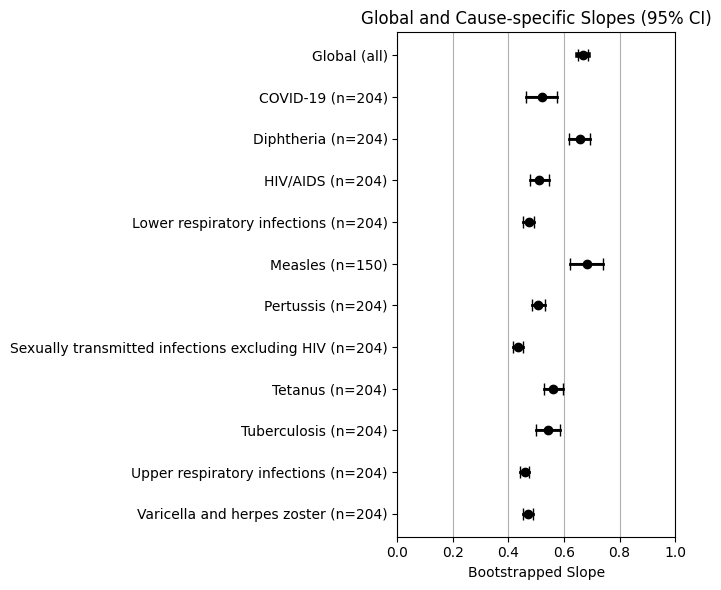

In [ ]:
# # Cell 6: Plot log10(q) and Ouput Stats
# Assign grouping variable (cause) for each data point
cause = np.array(pivoted['epi_cause_name'])[mask.values]
cause_list = np.unique(cause)

n_bootstrap = 1000

# Global bootstrap slope/CI
global_slopes = []
for _ in range(n_bootstrap):
    idx = np.random.randint(0, len(x), len(x))
    s, _ = np.polyfit(x[idx], y_R[idx], 1)
    global_slopes.append(s)
global_mean = np.mean(global_slopes)
global_lo, global_hi = np.percentile(global_slopes, [2.5, 97.5])

# Cause-specific bootstraps
cause_names, cause_means, cause_los, cause_his, cause_ns = [], [], [], [], []
for c in cause_list:
    idx_group = np.where(cause == c)[0]
    if len(idx_group) >= 5:  # Filter for enough data
        xg = x[idx_group]
        yg = y_R[idx_group]
        slopes = []
        for _ in range(n_bootstrap):
            idx_bs = np.random.randint(0, len(xg), len(xg))
            s_bs, _ = np.polyfit(xg[idx_bs], yg[idx_bs], 1)
            slopes.append(s_bs)
        cause_names.append(c)
        cause_means.append(np.mean(slopes))
        lo, hi = np.percentile(slopes, [2.5, 97.5])
        cause_los.append(lo)
        cause_his.append(hi)
        cause_ns.append(len(xg))

# Plotting
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 0.5 + 0.5*len(cause_means)))
labels = ['Global'] + list(cause_names)
means = [global_mean] + cause_means
los = [global_lo] + cause_los
his = [global_hi] + cause_his
sizes = ['all'] + [f'n={n}' for n in cause_ns]

y_pos = np.arange(len(means))
plt.errorbar(means, y_pos, xerr=[np.array(means)-np.array(los), np.array(his)-np.array(means)], fmt='o', capsize=4, color='black')
for i, (mean, lo, hi) in enumerate(zip(means, los, his)):
    plt.plot([lo, hi], [y_pos[i]]*2, color='black', lw=4 if i==0 else 2)
plt.yticks(y_pos, [f'{labels[i]} ({sizes[i]})' for i in range(len(labels))])
plt.xlabel('Bootstrapped Slope')
plt.title('Global and Cause-specific Slopes (95% CI)')
plt.gca().invert_yaxis()
plt.grid(axis='x')
plt.tight_layout()
plt.xlim(0, 1)
plt.savefig('/content/drive/My Drive/Hopeful Monsters/Projects/Mass Action 2025/Datasets/Epidemiology/global_cause_slopes.pdf', bbox_inches='tight')
# Printout table
print("Slope Summary:")
for i, label in enumerate(labels):
    print(f"{label:30}: mean={means[i]:.4f}, 95% CI=({los[i]:.4f}, {his[i]:.4f}), {sizes[i]}")



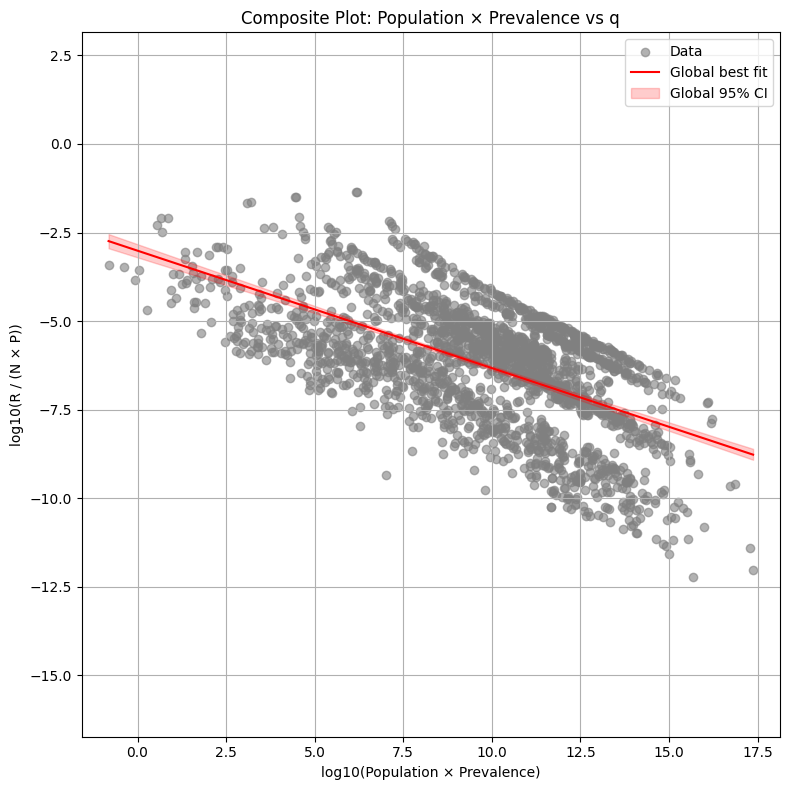

Global best fit slope: -0.3314
Global 95% bootstrap CI for slope: [-0.3488, -0.3125]
Global bootstrap R2 mean: 0.3434 (95% CI: 0.3173, 0.3695)


In [ ]:
# Cell: Plot q = log10(R / (N * P)) and Output Stats

# R = incidence (rate), N = population, P = prevalence
mask = R.notna() & N.notna() & P.notna() & (R > 0) & (N > 0) & (P > 0)
x = np.log10(N[mask].values * P[mask].values)  # log10(population * prevalence)
y_q = np.log10(R[mask].values / (N[mask].values * P[mask].values))  # log10(R / (N * P))

plt.figure(figsize=(8, 8))
plt.scatter(x, y_q, alpha=0.6, label='Data', color='grey')
plt.gca().set_aspect('equal', adjustable='datalim')  # Square plot with free axes

# Fit line and bootstrap
slope_q, intercept_q = np.polyfit(x, y_q, 1)
n_bootstrap = 1000
slopes_q = []
intercepts_q = []
r2_q = []
for _ in range(n_bootstrap):
    idx = np.random.randint(0, len(x), len(x))
    x_sample = x[idx]
    y_q_sample = y_q[idx]
    s, b = np.polyfit(x_sample, y_q_sample, 1)
    slopes_q.append(s)
    intercepts_q.append(b)
    y_pred = s * x_sample + b
    ss_res = np.sum((y_q_sample - y_pred) ** 2)
    ss_tot = np.sum((y_q_sample - np.mean(y_q_sample)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
    r2_q.append(r2)

# Prediction intervals
x_pred = np.linspace(np.min(x), np.max(x), 100)
y_pred_mat = np.array([s * x_pred + b for s, b in zip(slopes_q, intercepts_q)])
y_low, y_high = np.percentile(y_pred_mat, [2.5, 97.5], axis=0)
plt.plot(x_pred, slope_q * x_pred + intercept_q, color='red', label='Global best fit')
plt.fill_between(x_pred, y_low, y_high, color='red', alpha=0.2, label='Global 95% CI')

plt.xlabel('log10(Population × Prevalence)')
plt.ylabel('log10(R / (N × P))')
plt.title('Composite Plot: Population × Prevalence vs q')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/My Drive/Hopeful Monsters/Projects/Mass Action 2025/Datasets/Epidemiology/global_log10q_epidemiology_plot.pdf', bbox_inches='tight')
plt.show()

# Output summary statistics
slope_q_lo, slope_q_hi = np.percentile(slopes_q, [2.5, 97.5])
r2_q_mean = np.nanmean(r2_q)
r2_q_lo, r2_q_hi = np.nanpercentile(r2_q, [2.5, 97.5])

print(f"Global best fit slope: {slope_q:.4f}")
print(f"Global 95% bootstrap CI for slope: [{slope_q_lo:.4f}, {slope_q_hi:.4f}]")
print(f"Global bootstrap R2 mean: {r2_q_mean:.4f} (95% CI: {r2_q_lo:.4f}, {r2_q_hi:.4f})")




Mean log10(q):   -6.2322 [-6.3083, -6.1610]
Median log10(q): -6.0069 [-6.0860, -5.9413]
Mode log10(q):   -5.7894 [-5.9711, -5.5196]


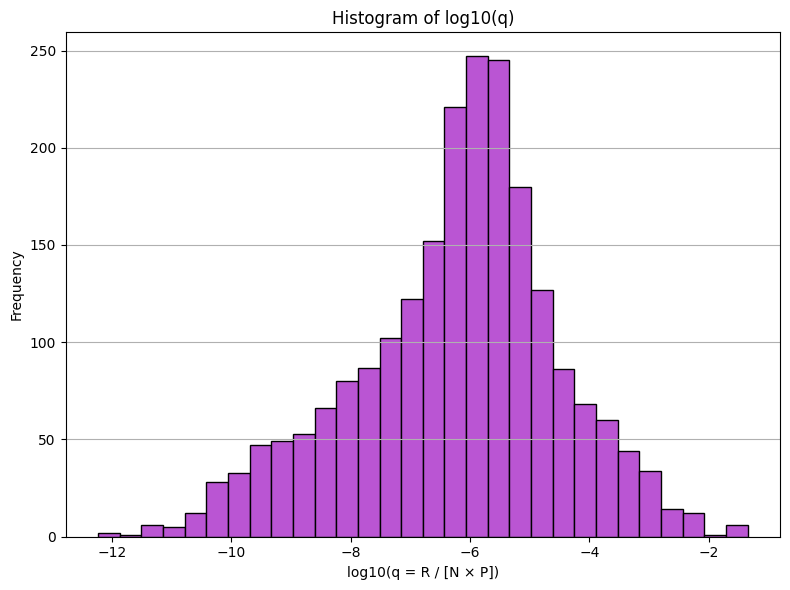

In [ ]:
# # Cell 8: Plot histogram of q frequencies

# Calculate q values as before
mask = R.notna() & N.notna() & P.notna() & (R > 0) & (N > 0) & (P > 0)
q = np.log10(R[mask].values / (N[mask].values * P[mask].values))  # Already log10 in q

# You do not need to re-log10, since q is already log10(R / NP)
qvals = q  # Just use as is

n_bootstrap = 1000
means = []
medians = []
modes = []

for _ in range(n_bootstrap):
    sample = np.random.choice(qvals, size=len(qvals), replace=True)
    means.append(np.mean(sample))
    medians.append(np.median(sample))
    hist, bin_edges = np.histogram(sample, bins=30)
    mode_idx = np.argmax(hist)
    mode_val = (bin_edges[mode_idx] + bin_edges[mode_idx + 1]) / 2
    modes.append(mode_val)

mean_val = np.mean(means)
mean_lo, mean_hi = np.percentile(means, [2.5, 97.5])
median_val = np.mean(medians)
median_lo, median_hi = np.percentile(medians, [2.5, 97.5])
mode_val = np.mean(modes)
mode_lo, mode_hi = np.percentile(modes, [2.5, 97.5])

print(f"Mean log10(q):   {mean_val:.4f} [{mean_lo:.4f}, {mean_hi:.4f}]")
print(f"Median log10(q): {median_val:.4f} [{median_lo:.4f}, {median_hi:.4f}]")
print(f"Mode log10(q):   {mode_val:.4f} [{mode_lo:.4f}, {mode_hi:.4f}]")

# Histogram plot
plt.figure(figsize=(8,6))
plt.hist(qvals, bins=30, color='mediumorchid', edgecolor='black')
plt.xlabel('log10(q = R / [N × P])')
plt.ylabel('Frequency')
plt.title('Histogram of log10(q)')
plt.grid(axis='y')
plt.tight_layout()
save_path = '/content/drive/My Drive/Hopeful Monsters/Projects/Mass Action 2025/Datasets/Viruses/q_histogram.pdf'
plt.savefig(save_path, bbox_inches='tight')
plt.show()




log10(R) Bootstrapped Slopes & R2:
COVID-19       : slope=0.519 [0.466,0.574], R2=0.958 [0.942,0.989], n=204
Diphtheria     : slope=0.656 [0.620,0.690], R2=0.874 [0.836,0.906], n=204
HIV/AIDS       : slope=0.512 [0.478,0.544], R2=0.874 [0.844,0.899], n=204
Lower respiratory infections: slope=0.473 [0.456,0.491], R2=0.971 [0.962,0.980], n=204
Measles        : slope=0.681 [0.624,0.736], R2=0.814 [0.765,0.860], n=150
Pertussis      : slope=0.508 [0.488,0.529], R2=0.942 [0.927,0.955], n=204
Sexually transmitted infections excluding HIV: slope=0.435 [0.416,0.454], R2=0.954 [0.942,0.964], n=204
Tetanus        : slope=0.562 [0.527,0.599], R2=0.826 [0.780,0.868], n=204
Tuberculosis   : slope=0.542 [0.497,0.587], R2=0.760 [0.707,0.806], n=204
Upper respiratory infections: slope=0.458 [0.444,0.472], R2=0.985 [0.978,0.992], n=204
Varicella and herpes zoster: slope=0.471 [0.452,0.488], R2=0.949 [0.938,0.960], n=204


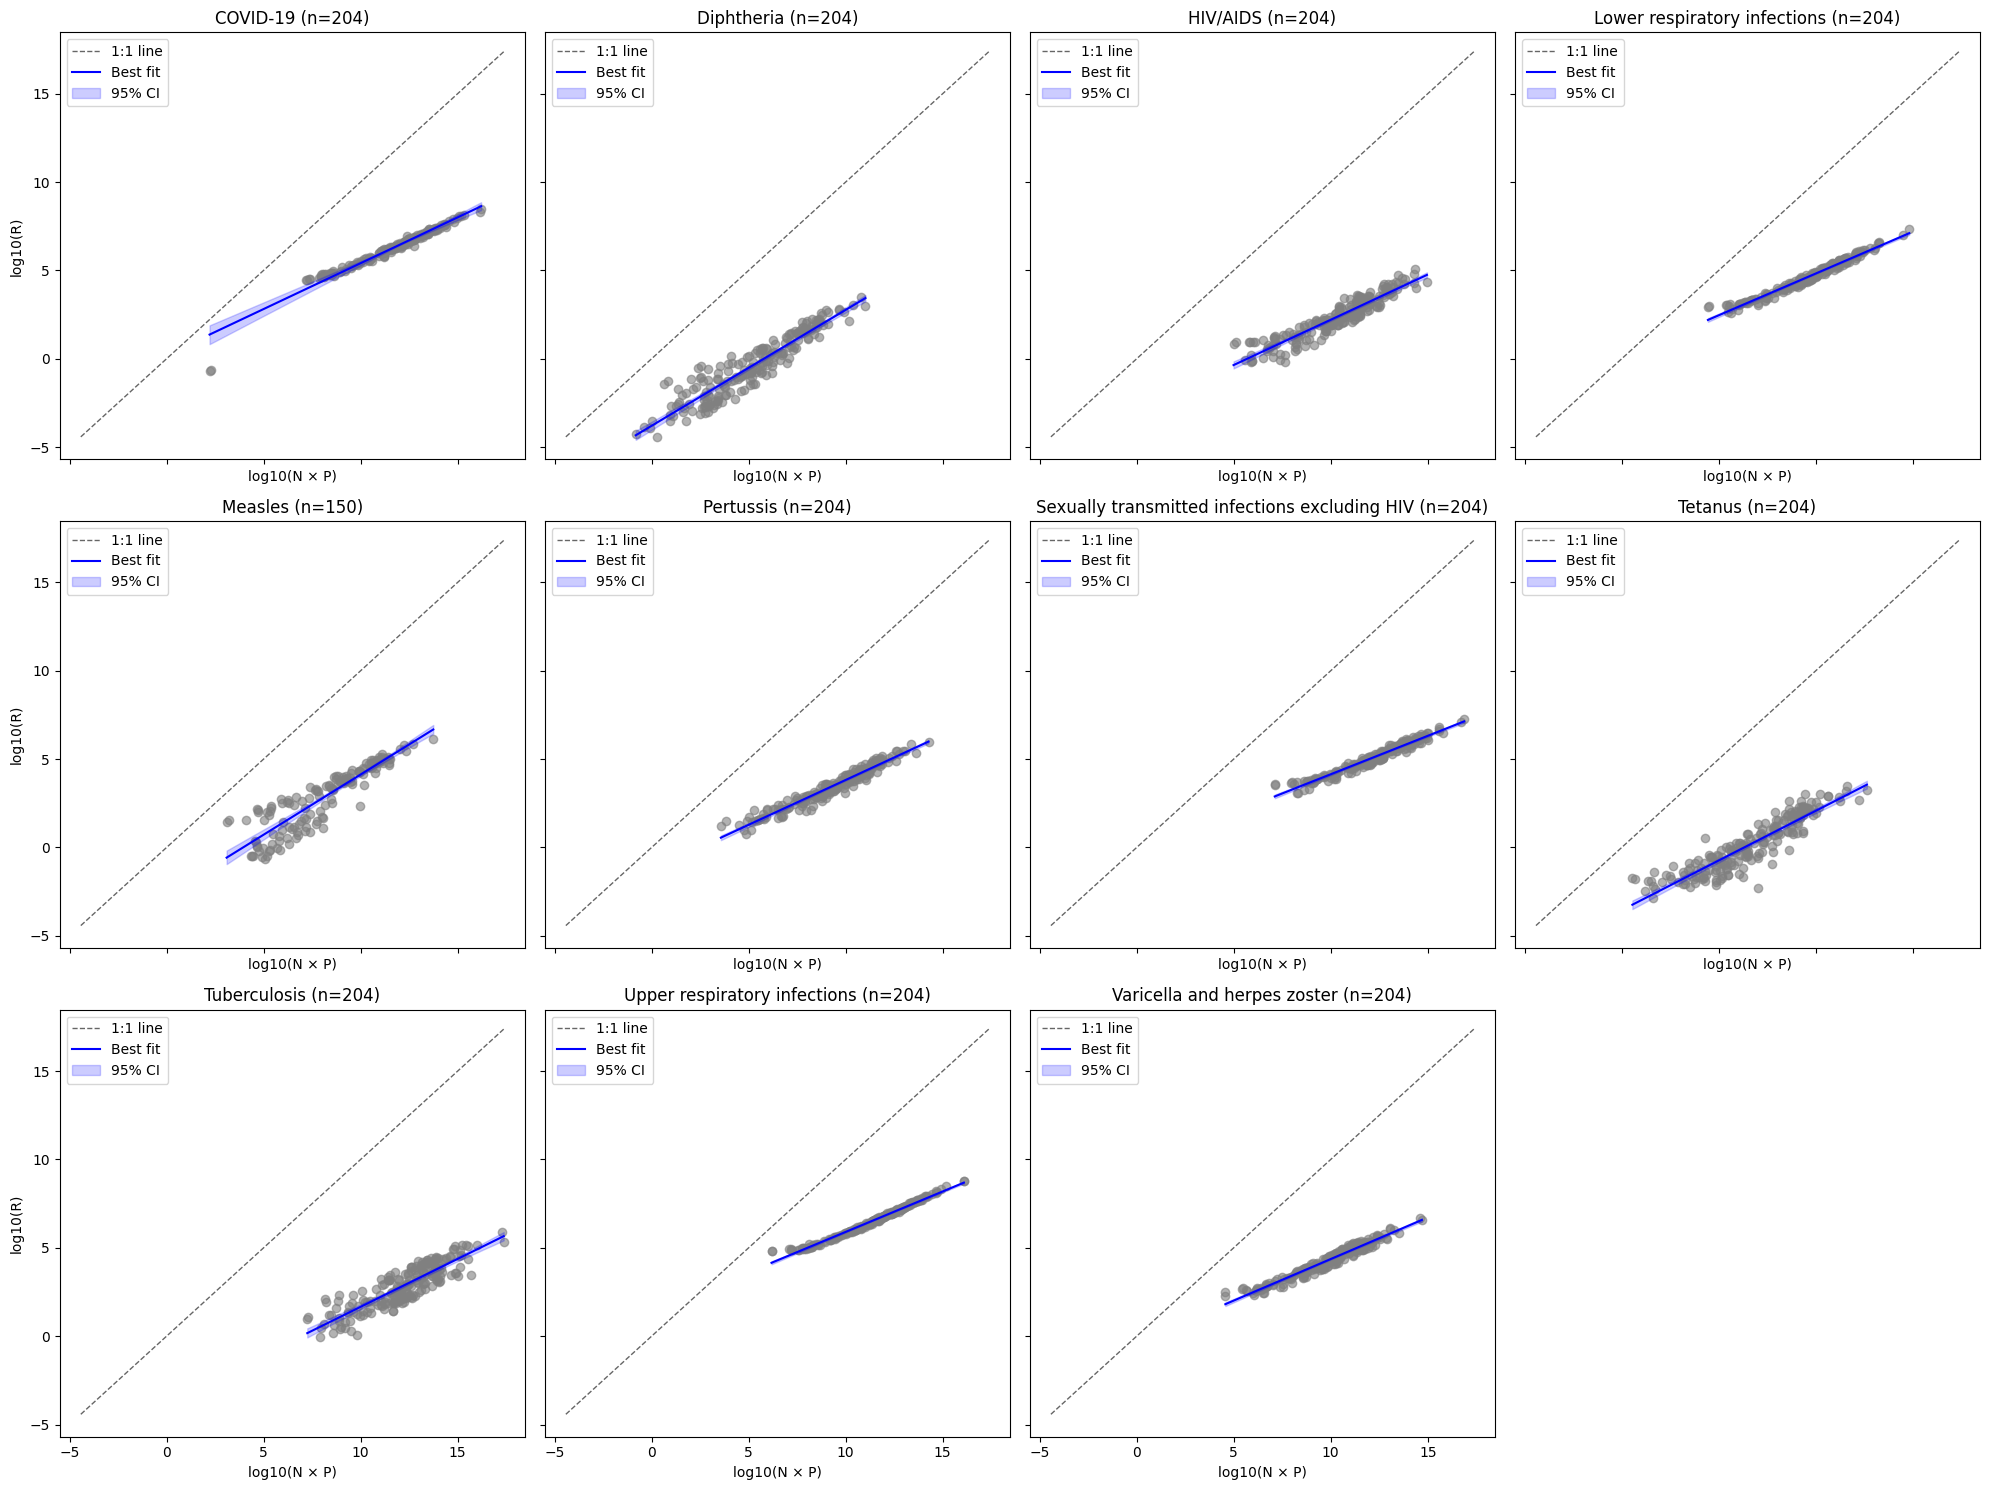

In [ ]:
# #Cell 10: Faceting R plots by illness

# Mask for complete and positive values
mask = (
    pivoted['R'].notna() & pivoted['N'].notna() & pivoted['P'].notna() &
    (pivoted['R'] > 0) & (pivoted['N'] > 0) & (pivoted['P'] > 0)
)

# Filtered columns for plotting
x_all = np.log10(pivoted.loc[mask, 'N'] * pivoted.loc[mask, 'P'])
y_all = np.log10(pivoted.loc[mask, 'R'])
cause_all = pivoted.loc[mask, 'epi_cause_name']

illness_list = cause_all.unique()
n_bootstrap = 1000
ncol = 4
nrow = int(np.ceil(len(illness_list) / ncol))

fig, axes = plt.subplots(nrow, ncol, figsize=(5*ncol, 5*nrow), sharex=True, sharey=True)
axes = axes.flatten()

global_min = min(x_all.min(), y_all.min())
global_max = max(x_all.max(), y_all.max())
lims = [global_min, global_max]

print('log10(R) Bootstrapped Slopes & R2:')
for i, illness in enumerate(illness_list):
    idx = (cause_all == illness)
    ax = axes[i]
    x_ill = x_all[idx]
    y_ill = y_all[idx]
    ax.scatter(x_ill, y_ill, color='grey', alpha=0.6)
    ax.plot(lims, lims, 'k--', alpha=0.6, lw=1, label='1:1 line')
    ax.set_title(f"{illness} (n={len(x_ill)})")
    ax.set_xlabel('log10(N × P)')
    if i % ncol == 0:
        ax.set_ylabel('log10(R)')
    if len(x_ill) >= 5:
        slopes = []
        intercepts = []
        r2s = []
        for _ in range(n_bootstrap):
            boot_idx = np.random.randint(0, len(x_ill), len(x_ill))
            x_boot = x_ill.values[boot_idx]
            y_boot = y_ill.values[boot_idx]
            s, b = np.polyfit(x_boot, y_boot, 1)
            slopes.append(s)
            intercepts.append(b)
            y_pred = s * x_boot + b
            ss_res = np.sum((y_boot - y_pred) ** 2)
            ss_tot = np.sum((y_boot - np.mean(y_boot)) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
            r2s.append(r2)
        mean_slope = np.mean(slopes)
        mean_intercept = np.mean(intercepts)
        slope_lo, slope_hi = np.percentile(slopes, [2.5, 97.5])
        r2_mean = np.nanmean(r2s)
        r2_lo, r2_hi = np.nanpercentile(r2s, [2.5, 97.5])
        x_pred = np.linspace(np.min(x_ill), np.max(x_ill), 100)
        y_pred_mat = np.array([s * x_pred + b for s, b in zip(slopes, intercepts)])
        y_low, y_high = np.percentile(y_pred_mat, [2.5, 97.5], axis=0)
        ax.plot(x_pred, mean_slope * x_pred + mean_intercept, color='blue', label='Best fit')
        ax.fill_between(x_pred, y_low, y_high, color='blue', alpha=0.2, label='95% CI')
        ax.legend()
        print(f"{illness:15}: slope={mean_slope:.3f} [{slope_lo:.3f},{slope_hi:.3f}], "
              f"R2={r2_mean:.3f} [{r2_lo:.3f},{r2_hi:.3f}], n={len(x_ill)}")
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
save_path = '/content/drive/My Drive/Hopeful Monsters/Projects/Mass Action 2025/Datasets/Epidemiology/logR_illness_panel.pdf'
plt.savefig(save_path, bbox_inches='tight')
plt.show()



log10(q) Bootstrapped Slopes & R2:
COVID-19       : slope=-0.485 [-0.535,-0.428], R2=0.949 [0.908,0.991], n=204
Diphtheria     : slope=-0.343 [-0.378,-0.309], R2=0.657 [0.591,0.716], n=204
HIV/AIDS       : slope=-0.488 [-0.520,-0.451], R2=0.862 [0.827,0.891], n=204
Lower respiratory infections: slope=-0.528 [-0.546,-0.510], R2=0.977 [0.971,0.982], n=204
Measles        : slope=-0.321 [-0.385,-0.262], R2=0.494 [0.391,0.598], n=150
Pertussis      : slope=-0.492 [-0.513,-0.471], R2=0.938 [0.920,0.952], n=204
Sexually transmitted infections excluding HIV: slope=-0.565 [-0.583,-0.547], R2=0.972 [0.966,0.978], n=204
Tetanus        : slope=-0.439 [-0.473,-0.402], R2=0.746 [0.670,0.804], n=204
Tuberculosis   : slope=-0.459 [-0.502,-0.416], R2=0.694 [0.624,0.753], n=204
Upper respiratory infections: slope=-0.542 [-0.557,-0.528], R2=0.990 [0.986,0.994], n=204
Varicella and herpes zoster: slope=-0.530 [-0.548,-0.511], R2=0.959 [0.949,0.969], n=204


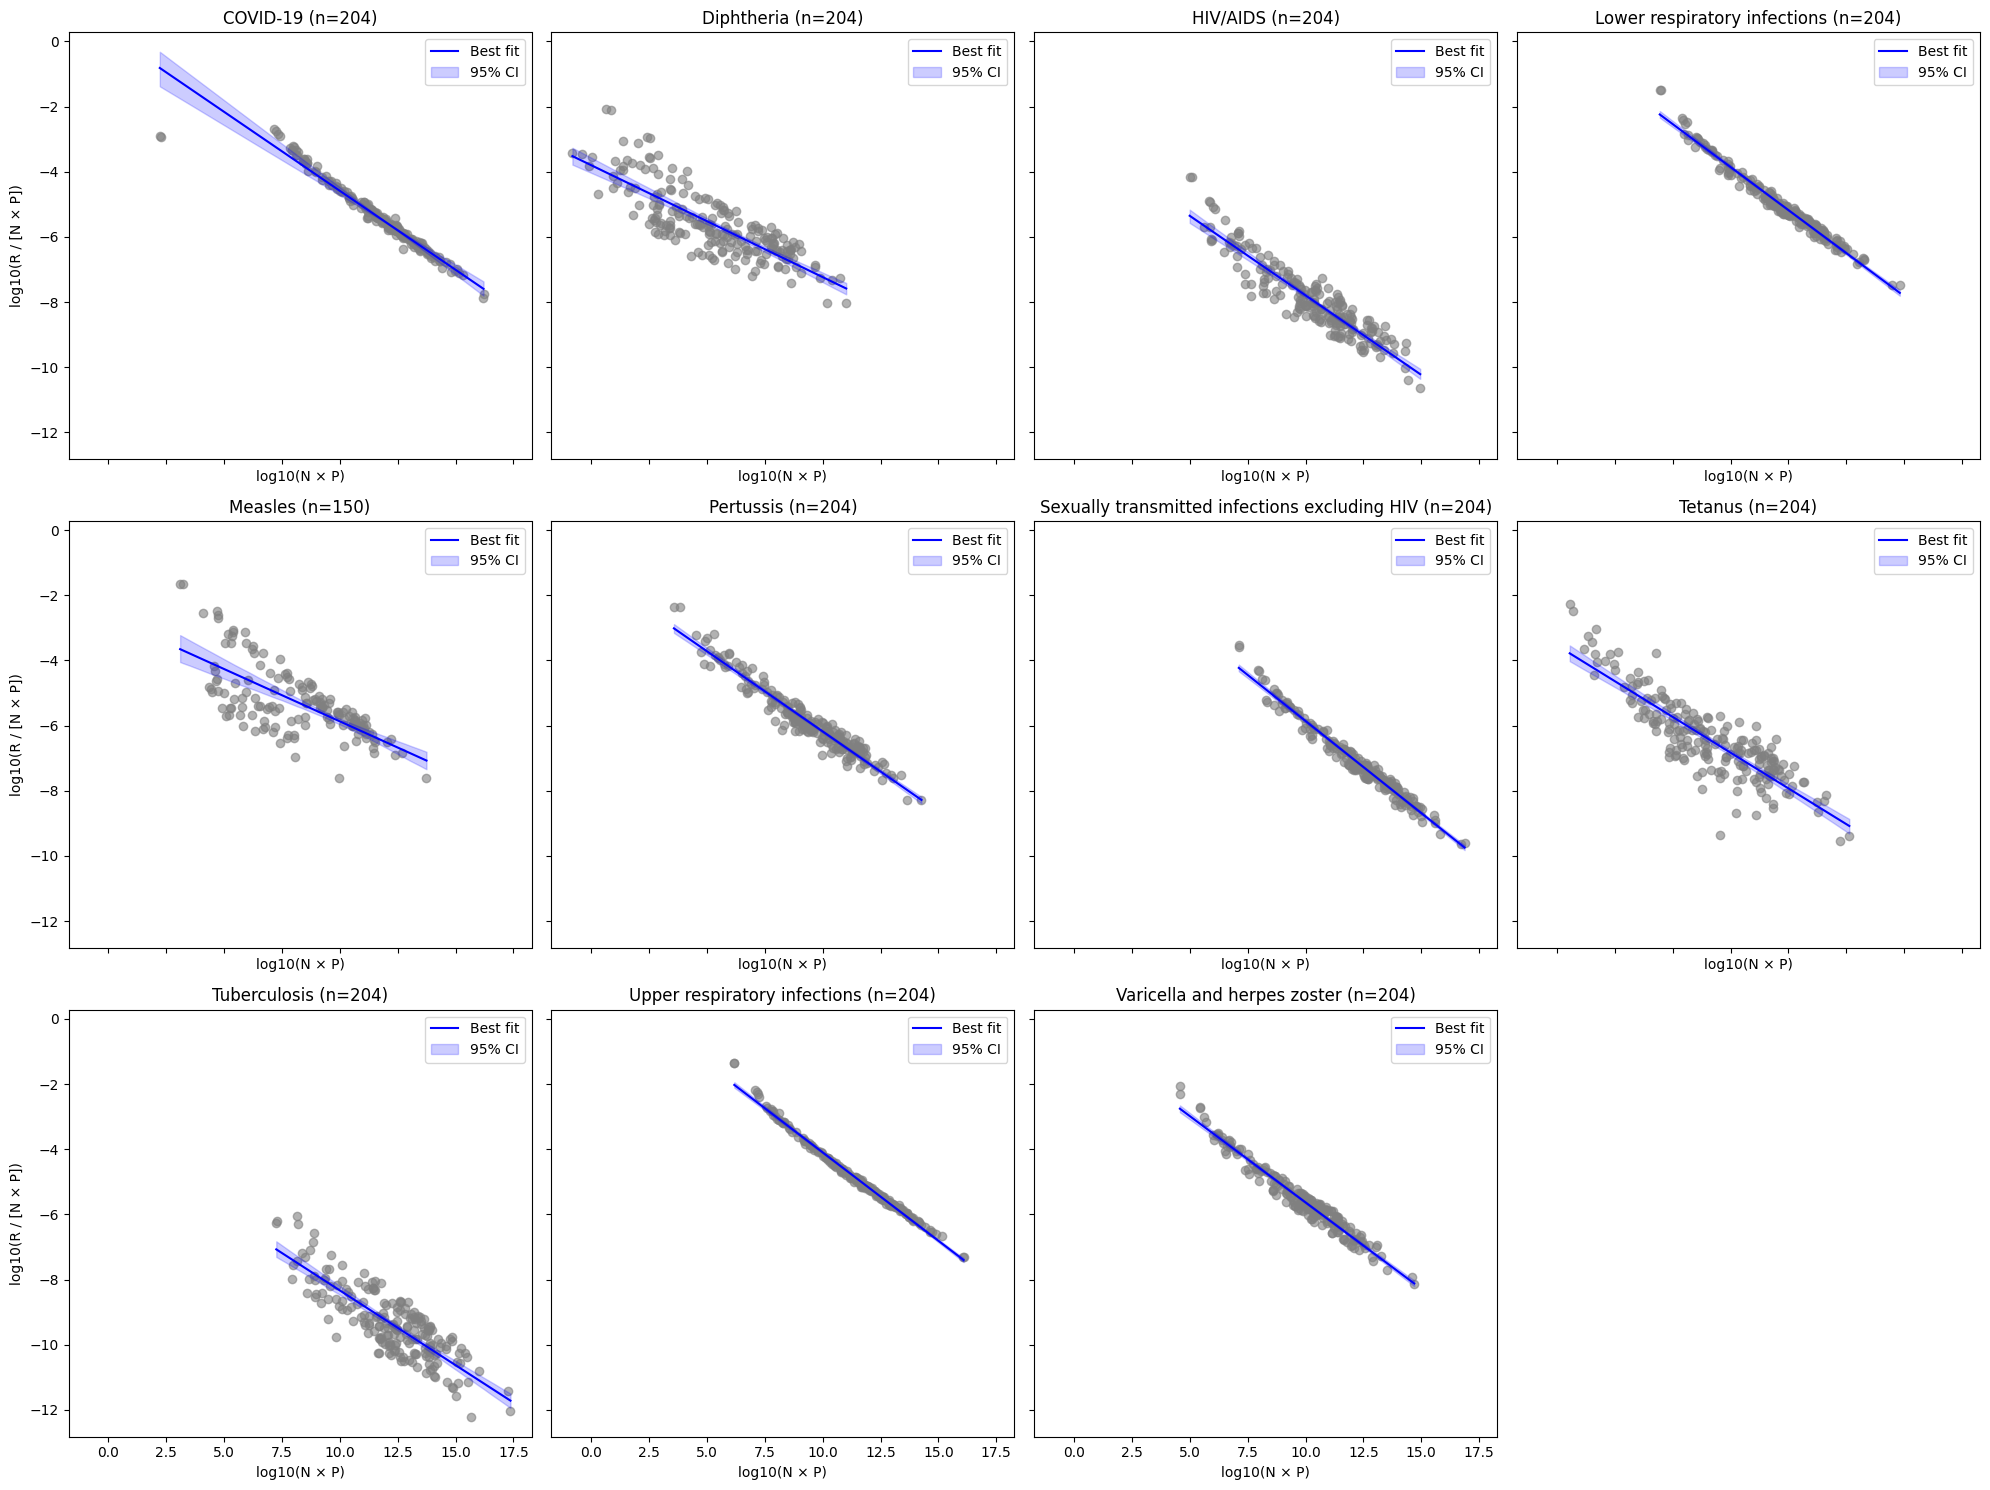

In [ ]:
# Faceting q plots by illness/cause using aligned DataFrame (pivoted)

# Mask for complete and positive values
mask = (
    pivoted['R'].notna() & pivoted['N'].notna() & pivoted['P'].notna() &
    (pivoted['R'] > 0) & (pivoted['N'] > 0) & (pivoted['P'] > 0)
)

# Filtered columns for plotting
x_all = np.log10(pivoted.loc[mask, 'N'] * pivoted.loc[mask, 'P'])
y_all = np.log10(pivoted.loc[mask, 'R'] / (pivoted.loc[mask, 'N'] * pivoted.loc[mask, 'P']))
cause_all = pivoted.loc[mask, 'epi_cause_name']

illness_list = cause_all.unique()
n_bootstrap = 1000
ncol = 4
nrow = int(np.ceil(len(illness_list) / ncol))

fig, axes = plt.subplots(nrow, ncol, figsize=(5*ncol, 5*nrow), sharex=True, sharey=True)
axes = axes.flatten()

print('log10(q) Bootstrapped Slopes & R2:')
for i, illness in enumerate(illness_list):
    idx = (cause_all == illness)
    ax = axes[i]
    x_ill = x_all[idx]
    y_ill = y_all[idx]
    ax.scatter(x_ill, y_ill, color='grey', alpha=0.6)
    ax.set_title(f"{illness} (n={len(x_ill)})")
    ax.set_xlabel('log10(N × P)')
    if i % ncol == 0:
        ax.set_ylabel('log10(R / [N × P])')
    if len(x_ill) >= 5:
        slopes = []
        intercepts = []
        r2s = []
        for _ in range(n_bootstrap):
            boot_idx = np.random.randint(0, len(x_ill), len(x_ill))
            x_boot = x_ill.values[boot_idx]
            y_boot = y_ill.values[boot_idx]
            s, b = np.polyfit(x_boot, y_boot, 1)
            slopes.append(s)
            intercepts.append(b)
            y_pred = s * x_boot + b
            ss_res = np.sum((y_boot - y_pred) ** 2)
            ss_tot = np.sum((y_boot - np.mean(y_boot)) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
            r2s.append(r2)
        mean_slope = np.mean(slopes)
        mean_intercept = np.mean(intercepts)
        slope_lo, slope_hi = np.percentile(slopes, [2.5, 97.5])
        r2_mean = np.nanmean(r2s)
        r2_lo, r2_hi = np.nanpercentile(r2s, [2.5, 97.5])
        x_pred = np.linspace(np.min(x_ill), np.max(x_ill), 100)
        y_pred_mat = np.array([s * x_pred + b for s, b in zip(slopes, intercepts)])
        y_low, y_high = np.percentile(y_pred_mat, [2.5, 97.5], axis=0)
        ax.plot(x_pred, mean_slope * x_pred + mean_intercept, color='blue', label='Best fit')
        ax.fill_between(x_pred, y_low, y_high, color='blue', alpha=0.2, label='95% CI')
        ax.legend()
        print(f"{illness:15}: slope={mean_slope:.3f} [{slope_lo:.3f},{slope_hi:.3f}], "
              f"R2={r2_mean:.3f} [{r2_lo:.3f},{r2_hi:.3f}], n={len(x_ill)}")
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
save_path = '/content/drive/My Drive/Hopeful Monsters/Projects/Mass Action 2025/Datasets/Epidemiology/logq_illness_panel.pdf'
plt.savefig(save_path, bbox_inches='tight')
plt.show()






In [ ]:
# Cell 11: Poisson Thinning Analysis for Epidemiology (PORTED FROM VIRAL CODE)

# Calculate Poisson thinning expectation (parallel to viral pt)
# pt = N * (1 - exp(-P/N)) where P/N is "infection multiplicity"
mask = R.notna() & N.notna() & P.notna() & (R > 0) & (N > 0) & (P > 0)
N_valid = N[mask].values
P_valid = P[mask].values
R_valid = R[mask].values

pt = N_valid * (1 - np.exp(-P_valid / N_valid))  # Poisson thinning expectation

# Required q if mass action is explanatory (already calculated as R/(N*P))
req_q = R_valid / (N_valid * P_valid)

# Required z (only where R < N), from Poisson model: z = -N/P * log(1 - R/N)
mask_z = mask & (R < N)
N_z = N[mask_z].values
P_z = P[mask_z].values
R_z = R[mask_z].values
req_z = -N_z / P_z * np.log(1 - R_z / N_z)

print(f"Poisson thinning analysis ready:")
print(f"  pt values: {len(pt):,}")
print(f"  req_q values: {len(req_q):,}")
print(f"  req_z values: {len(req_z):,}")

Poisson thinning analysis ready:
  pt values: 2,190
  req_q values: 2,190
  req_z values: 2,151


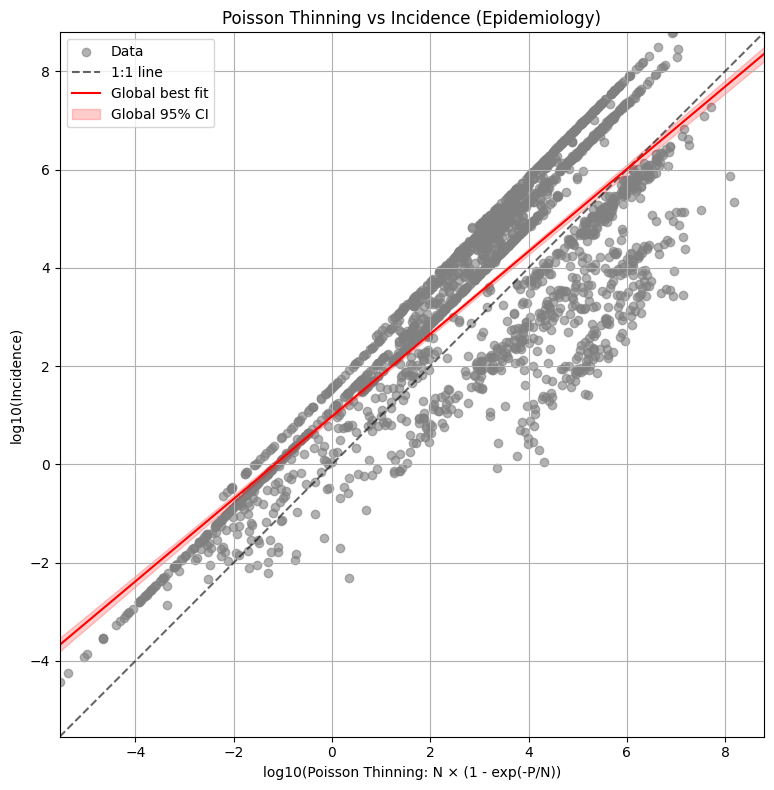

Poisson thinning slope: 0.8389 [0.8196, 0.8575]
R2: 0.7214 [0.6975, 0.7431]


In [ ]:
# Cell 12: Plot log10(R) vs log10(Poisson Thinning Expectation) and Output Stats (PORTED)

plt.figure(figsize=(8,8))
plt.scatter(np.log10(pt), np.log10(R_valid), alpha=0.6, label='Data', color='grey')
lims = [min(np.log10(pt).min(), np.log10(R_valid).min()), max(np.log10(pt).max(), np.log10(R_valid).max())]
plt.plot(lims, lims, 'k--', alpha=0.6, label='1:1 line')
plt.xlim(lims)
plt.ylim(lims)

# Fit and bootstrap (identical structure to viral code)
slope_pt, intercept_pt = np.polyfit(np.log10(pt), np.log10(R_valid), 1)
n_bootstrap = 1000
slopes_pt = []
intercepts_pt = []
r2_pt = []
for _ in range(n_bootstrap):
    idx = np.random.randint(0, len(pt), len(pt))
    x_sample = np.log10(pt)[idx]
    y_sample = np.log10(R_valid)[idx]
    s, b = np.polyfit(x_sample, y_sample, 1)
    slopes_pt.append(s)
    intercepts_pt.append(b)
    y_pred = s * x_sample + b
    ss_res = np.sum((y_sample - y_pred)**2)
    ss_tot = np.sum((y_sample - np.mean(y_sample))**2)
    r2_ = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
    r2_pt.append(r2_)

x_pred = np.linspace(lims[0], lims[1], 100)
y_pred_mat = np.array([s * x_pred + b for s, b in zip(slopes_pt, intercepts_pt)])
y_low, y_high = np.percentile(y_pred_mat, [2.5, 97.5], axis=0)
plt.plot(x_pred, slope_pt * x_pred + intercept_pt, color='red', label='Global best fit')
plt.fill_between(x_pred, y_low, y_high, color='red', alpha=0.2, label='Global 95% CI')
plt.xlabel('log10(Poisson Thinning: N × (1 - exp(-P/N))')
plt.ylabel('log10(Incidence)')
plt.title('Poisson Thinning vs Incidence (Epidemiology)')
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/My Drive/Hopeful Monsters/Projects/Mass Action 2025/Datasets/Epidemiology/global_log10R_pt_epidemiology_plot.pdf', bbox_inches='tight')
plt.show()

slope_pt_lo, slope_pt_hi = np.percentile(slopes_pt, [2.5, 97.5])
r2_pt_mean = np.nanmean(r2_pt)
r2_pt_lo, r2_pt_hi = np.nanpercentile(r2_pt, [2.5, 97.5])
print(f"Poisson thinning slope: {slope_pt:.4f} [{slope_pt_lo:.4f}, {slope_pt_hi:.4f}]")
print(f"R2: {r2_pt_mean:.4f} [{r2_pt_lo:.4f}, {r2_pt_hi:.4f}]")

log10(R) Bootstrapped Slopes & R2 (Poisson thinning by cause):
COVID-19            : slope=1.047 [0.998,1.091], R2=0.995, n=204
Diphtheria          : slope=1.000 [1.000,1.000], R2=1.000, n=204
HIV/AIDS            : slope=0.937 [0.912,0.961], R2=0.961, n=204
Lower respiratory infections: slope=0.995 [0.993,0.998], R2=1.000, n=204
Measles             : slope=0.999 [0.999,1.000], R2=1.000, n=150
Pertussis           : slope=1.000 [1.000,1.000], R2=1.000, n=204
Sexually transmitted infections excluding HIV: slope=0.940 [0.907,0.973], R2=0.967, n=204
Tetanus             : slope=0.876 [0.839,0.912], R2=0.853, n=204
Tuberculosis        : slope=1.150 [1.066,1.237], R2=0.799, n=204
Upper respiratory infections: slope=0.996 [0.993,0.999], R2=1.000, n=204
Varicella and herpes zoster: slope=1.019 [0.989,1.049], R2=0.954, n=204


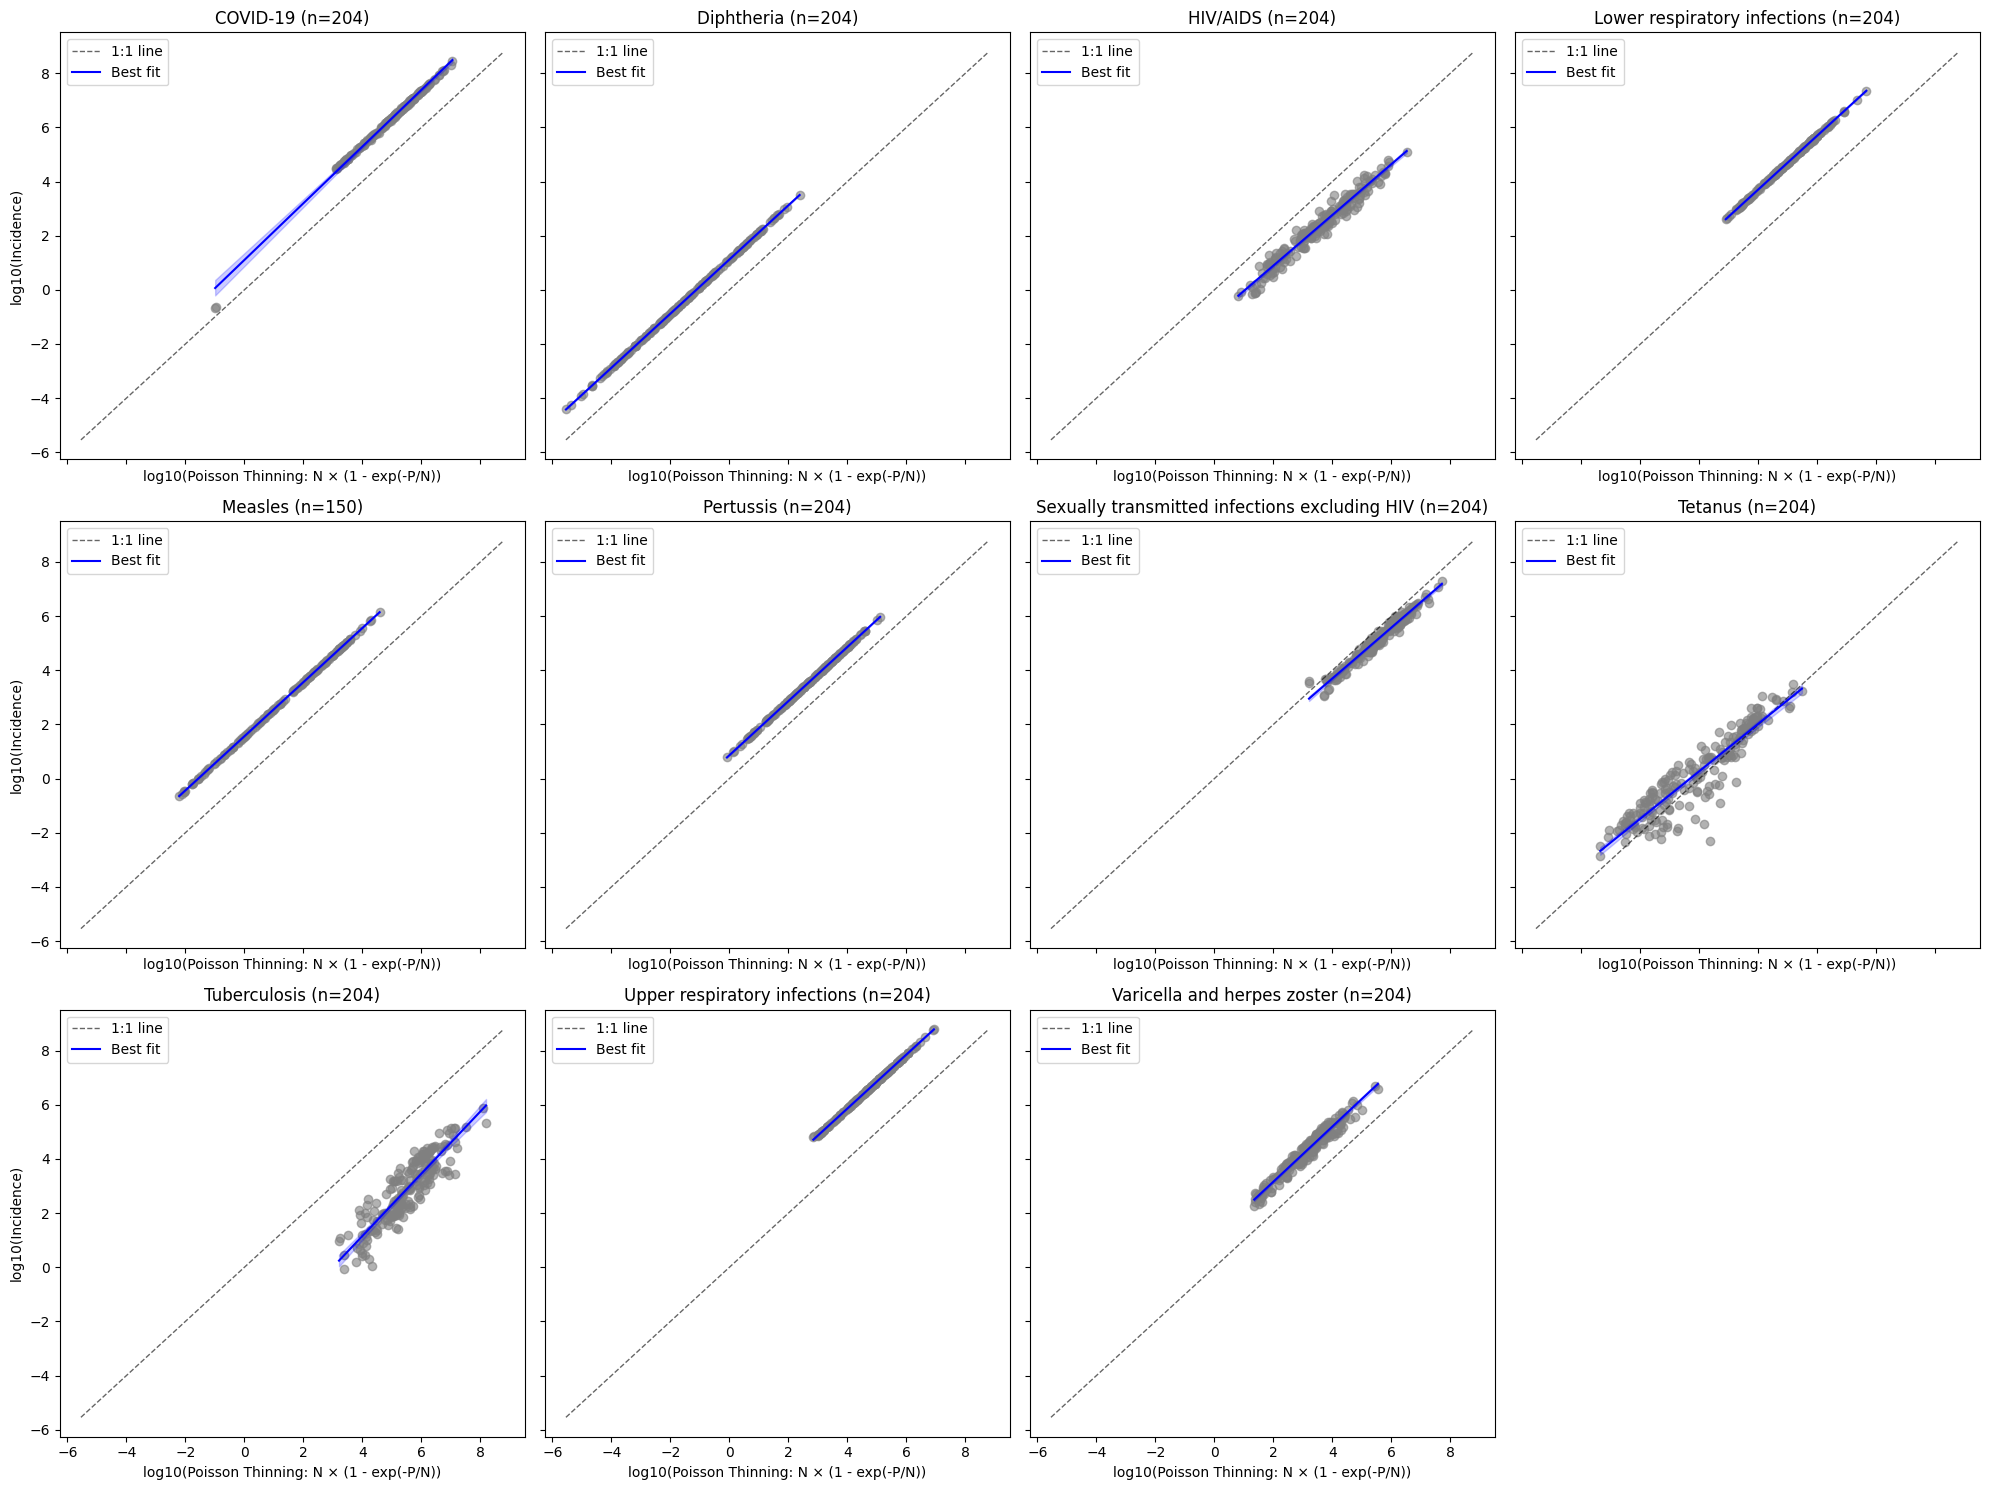

In [ ]:
# Cell 13: Faceting R plots by cause (Poisson thinning model) (PORTED)

cause = np.array(pivoted['epi_cause_name'])[mask.values]
cause_list = np.unique(cause)
n_bootstrap = 1000
ncol = 4
nrow = int(np.ceil(len(cause_list) / ncol))

x_all = np.log10(pt)
y_all = np.log10(R_valid)
global_min = min(x_all.min(), y_all.min())
global_max = max(x_all.max(), y_all.max())
lims = [global_min, global_max]

fig, axes = plt.subplots(nrow, ncol, figsize=(5*ncol, 5*nrow), sharex=True, sharey=True)
axes = axes.flatten()

print('log10(R) Bootstrapped Slopes & R2 (Poisson thinning by cause):')
for i, illness in enumerate(cause_list):
    idx = (cause == illness)
    ax = axes[i]
    x_cause = x_all[idx]
    y_cause = y_all[idx]
    ax.scatter(x_cause, y_cause, color='grey', alpha=0.6)
    ax.plot(lims, lims, 'k--', alpha=0.6, lw=1, label='1:1 line')
    ax.set_title(f"{illness} (n={len(x_cause)})")
    ax.set_xlabel('log10(Poisson Thinning: N × (1 - exp(-P/N))')
    if i % ncol == 0:
        ax.set_ylabel('log10(Incidence)')
    if len(x_cause) >= 5:
        slopes = []
        intercepts = []
        r2s = []
        for _ in range(n_bootstrap):
            boot_idx = np.random.randint(0, len(x_cause), len(x_cause))
            x_boot = x_cause[boot_idx]
            y_boot = y_cause[boot_idx]
            s, b = np.polyfit(x_boot, y_boot, 1)
            slopes.append(s)
            intercepts.append(b)
            y_pred = s * x_boot + b
            ss_res = np.sum((y_boot - y_pred)**2)
            ss_tot = np.sum((y_boot - np.mean(y_boot))**2)
            r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
            r2s.append(r2)
        mean_slope = np.mean(slopes)
        slope_lo, slope_hi = np.percentile(slopes, [2.5, 97.5])
        r2_mean = np.nanmean(r2s)
        x_pred = np.linspace(x_cause.min(), x_cause.max(), 100)
        y_pred_mat = np.array([s * x_pred + b for s, b in zip(slopes, intercepts)])
        y_low, y_high = np.percentile(y_pred_mat, [2.5, 97.5], axis=0)
        ax.plot(x_pred, mean_slope * x_pred + np.mean(intercepts), color='blue', label='Best fit')
        ax.fill_between(x_pred, y_low, y_high, color='blue', alpha=0.2)
        ax.legend()
        print(f"{illness:20}: slope={mean_slope:.3f} [{slope_lo:.3f},{slope_hi:.3f}], R2={r2_mean:.3f}, n={len(x_cause)}")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('/content/drive/My Drive/Hopeful Monsters/Projects/Mass Action 2025/Datasets/Epidemiology/logR_cause_panel_pt.pdf', bbox_inches='tight')
plt.show()

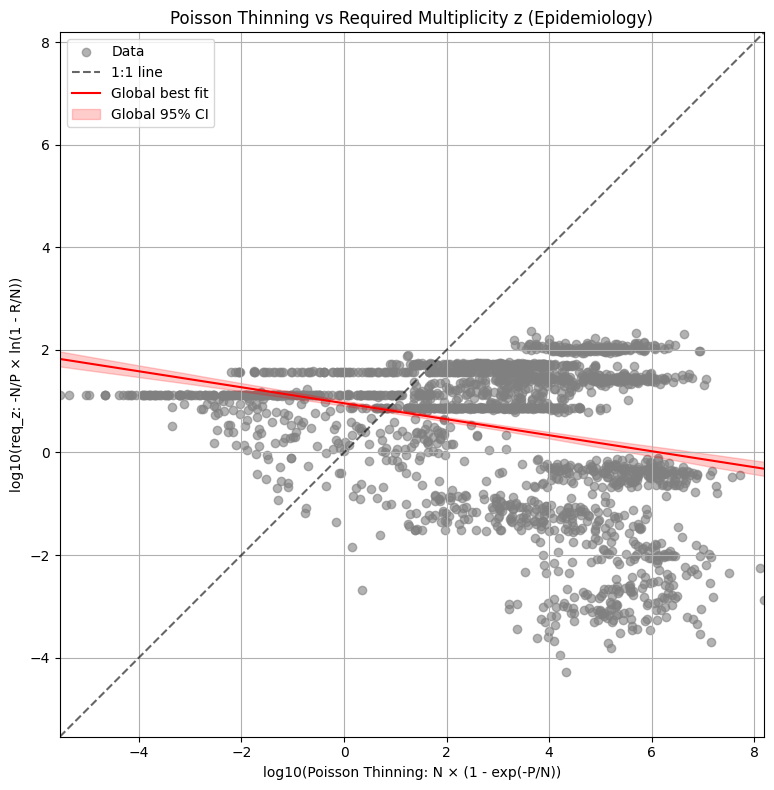

req_z slope: -0.1559 [-0.1757, -0.1367]
R2: 0.0798


In [ ]:
# Cell 14: Plot log10(req_z) vs log10(Poisson Thinning) and Output Stats (PORTED)

# Filter for valid z analysis (R < N, finite values)
valid_z = (
    (~np.isnan(pt_z := N_z * (1 - np.exp(-P_z / N_z)))) &
    (~np.isnan(req_z)) &
    (pt_z > 0) & (req_z > 0) &
    np.isfinite(pt_z) & np.isfinite(req_z)
)

x_z = np.log10(pt_z[valid_z])
y_req_z = np.log10(req_z[valid_z])

plt.figure(figsize=(8,8))
plt.scatter(x_z, y_req_z, alpha=0.6, label='Data', color='grey')
lims_z = [min(x_z.min(), y_req_z.min()), max(x_z.max(), y_req_z.max())]
plt.plot(lims_z, lims_z, 'k--', alpha=0.6, label='1:1 line')
plt.xlim(lims_z)
plt.ylim(lims_z)

slope_z, intercept_z = np.polyfit(x_z, y_req_z, 1)
n_bootstrap = 1000
slopes_z = []
intercepts_z = []
r2_z = []
for _ in range(n_bootstrap):
    idx = np.random.randint(0, len(x_z), len(x_z))
    x_sample = x_z[idx]
    y_sample = y_req_z[idx]
    s, b = np.polyfit(x_sample, y_sample, 1)
    slopes_z.append(s)
    intercepts_z.append(b)
    y_pred = s * x_sample + b
    ss_res = np.sum((y_sample - y_pred)**2)
    ss_tot = np.sum((y_sample - np.mean(y_sample))**2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
    r2_z.append(r2)

x_pred_z = np.linspace(lims_z[0], lims_z[1], 100)
y_pred_mat_z = np.array([s * x_pred_z + b for s, b in zip(slopes_z, intercepts_z)])
y_low_z, y_high_z = np.percentile(y_pred_mat_z, [2.5, 97.5], axis=0)
plt.plot(x_pred_z, slope_z * x_pred_z + intercept_z, color='red', label='Global best fit')
plt.fill_between(x_pred_z, y_low_z, y_high_z, color='red', alpha=0.2, label='Global 95% CI')
plt.xlabel('log10(Poisson Thinning: N × (1 - exp(-P/N))')
plt.ylabel('log10(req_z: -N/P × ln(1 - R/N))')
plt.title('Poisson Thinning vs Required Multiplicity z (Epidemiology)')
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/My Drive/Hopeful Monsters/Projects/Mass Action 2025/Datasets/Epidemiology/global_log10z_epidemiology_plot.pdf', bbox_inches='tight')
plt.show()

slope_z_lo, slope_z_hi = np.percentile(slopes_z, [2.5, 97.5])
r2_z_mean = np.nanmean(r2_z)
print(f"req_z slope: {slope_z:.4f} [{slope_z_lo:.4f}, {slope_z_hi:.4f}]")
print(f"R2: {r2_z_mean:.4f}")

Mean log10(req_z):   0.4938 [0.4321, 0.5562]
Median log10(req_z): 1.0822 [0.9531, 1.1237]
Mode log10(req_z):   1.2566 [0.8940, 1.6579]


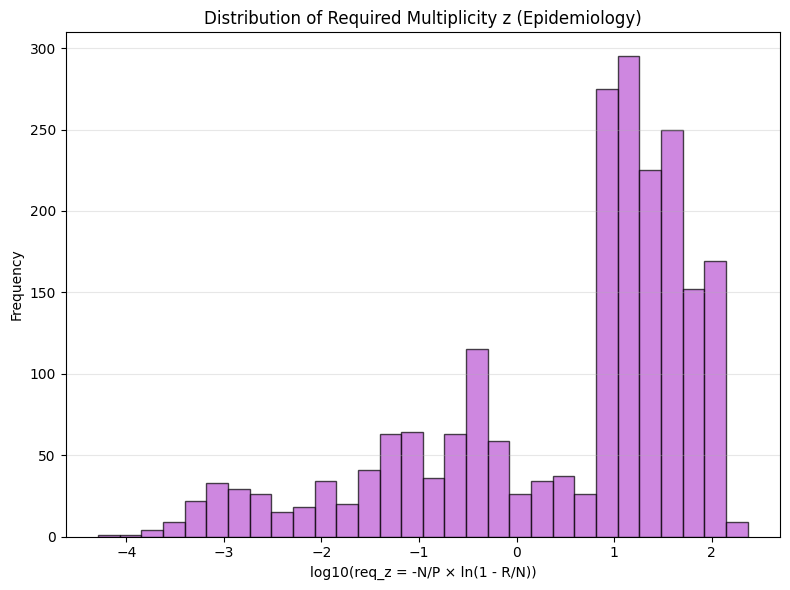

In [ ]:
# Cell 15: Histogram of req_z frequencies (PORTED)

zvals = req_z[valid_z]
logz = np.log10(zvals)
n_bootstrap = 1000

means_z, medians_z, modes_z = [], [], []
for _ in range(n_bootstrap):
    sample = np.random.choice(logz, size=len(logz), replace=True)
    means_z.append(np.mean(sample))
    medians_z.append(np.median(sample))
    hist, bin_edges = np.histogram(sample, bins=30)
    mode_idx = np.argmax(hist)
    mode_val = (bin_edges[mode_idx] + bin_edges[mode_idx + 1]) / 2
    modes_z.append(mode_val)

print(f"Mean log10(req_z):   {np.mean(means_z):.4f} [{np.percentile(means_z, 2.5):.4f}, {np.percentile(means_z, 97.5):.4f}]")
print(f"Median log10(req_z): {np.mean(medians_z):.4f} [{np.percentile(medians_z, 2.5):.4f}, {np.percentile(medians_z, 97.5):.4f}]")
print(f"Mode log10(req_z):   {np.mean(modes_z):.4f} [{np.percentile(modes_z, 2.5):.4f}, {np.percentile(modes_z, 97.5):.4f}]")

plt.figure(figsize=(8,6))
plt.hist(logz, bins=30, color='mediumorchid', edgecolor='black', alpha=0.7)
plt.xlabel('log10(req_z = -N/P × ln(1 - R/N))')
plt.ylabel('Frequency')
plt.title('Distribution of Required Multiplicity z (Epidemiology)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/My Drive/Hopeful Monsters/Projects/Mass Action 2025/Datasets/Epidemiology/z_histogram_epidemiology.pdf', bbox_inches='tight')
plt.show()

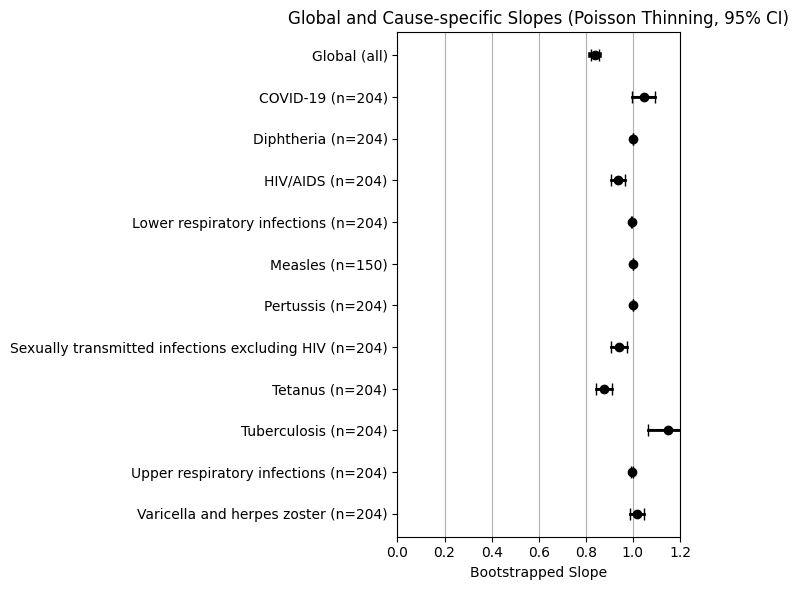

Poisson Thinning Slope Summary:
Global                        : mean=0.8386, 95% CI=(0.8204, 0.8571), all
COVID-19                      : mean=1.0475, 95% CI=(0.9976, 1.0919), n=204
Diphtheria                    : mean=1.0000, 95% CI=(1.0000, 1.0000), n=204
HIV/AIDS                      : mean=0.9368, 95% CI=(0.9090, 0.9652), n=204
Lower respiratory infections  : mean=0.9954, 95% CI=(0.9932, 0.9977), n=204
Measles                       : mean=0.9995, 95% CI=(0.9991, 0.9998), n=150
Pertussis                     : mean=1.0000, 95% CI=(1.0000, 1.0000), n=204
Sexually transmitted infections excluding HIV: mean=0.9415, 95% CI=(0.9082, 0.9734), n=204
Tetanus                       : mean=0.8759, 95% CI=(0.8420, 0.9109), n=204
Tuberculosis                  : mean=1.1487, 95% CI=(1.0644, 1.2333), n=204
Upper respiratory infections  : mean=0.9963, 95% CI=(0.9924, 0.9990), n=204
Varicella and herpes zoster   : mean=1.0186, 95% CI=(0.9885, 1.0474), n=204


In [ ]:
# Cell 16: Global + Cause Slopes Summary (Poisson Thinning) - PORTED FROM VIRAL

# Using variables from Cell 11
x_pt = np.log10(pt)
y_R_pt = np.log10(R_valid)
cause_pt = cause  # from Cell 13, matches mask
cause_list_pt = np.unique(cause_pt)
n_bootstrap = 1000

# Global bootstrap slope/CI (pt model)
global_slopes_pt = []
for _ in range(n_bootstrap):
    idx = np.random.randint(0, len(x_pt), len(x_pt))
    s, _ = np.polyfit(x_pt[idx], y_R_pt[idx], 1)
    global_slopes_pt.append(s)
global_mean_pt = np.mean(global_slopes_pt)
global_lo_pt, global_hi_pt = np.percentile(global_slopes_pt, [2.5, 97.5])

# Cause-specific bootstraps (pt model)
cause_names_pt, cause_means_pt, cause_los_pt, cause_his_pt, cause_ns_pt = [], [], [], [], []
for c in cause_list_pt:
    idx_group = np.where(cause_pt == c)[0]
    if len(idx_group) >= 5:
        xg = x_pt[idx_group]
        yg = y_R_pt[idx_group]
        slopes = []
        for _ in range(n_bootstrap):
            idx_bs = np.random.randint(0, len(xg), len(xg))
            s_bs, _ = np.polyfit(xg[idx_bs], yg[idx_bs], 1)
            slopes.append(s_bs)
        cause_names_pt.append(c)
        cause_means_pt.append(np.mean(slopes))
        lo, hi = np.percentile(slopes, [2.5, 97.5])
        cause_los_pt.append(lo)
        cause_his_pt.append(hi)
        cause_ns_pt.append(len(xg))

# Plotting (EXACT viral structure)
plt.figure(figsize=(7, 0.5 + 0.5*len(cause_means_pt)))
labels_pt = ['Global'] + cause_names_pt
means_pt = [global_mean_pt] + cause_means_pt
los_pt = [global_lo_pt] + cause_los_pt
his_pt = [global_hi_pt] + cause_his_pt
sizes_pt = ['all'] + [f'n={n}' for n in cause_ns_pt]

y_pos = np.arange(len(means_pt))
plt.errorbar(means_pt, y_pos, xerr=[np.array(means_pt)-np.array(los_pt), np.array(his_pt)-np.array(means_pt)], fmt='o', capsize=4, color='black')
for i, (mean, lo, hi) in enumerate(zip(means_pt, los_pt, his_pt)):
    plt.plot([lo, hi], [y_pos[i]]*2, color='black', lw=4 if i==0 else 2)
plt.yticks(y_pos, [f'{labels_pt[i]} ({sizes_pt[i]})' for i in range(len(labels_pt))])
plt.xlabel('Bootstrapped Slope')
plt.title('Global and Cause-specific Slopes (Poisson Thinning, 95% CI)')
plt.gca().invert_yaxis()
plt.grid(axis='x')
plt.tight_layout()
plt.xlim(0, 1.2)
plt.savefig('/content/drive/My Drive/Hopeful Monsters/Projects/Mass Action 2025/Datasets/Epidemiology/global_cause_slopes_pt.pdf', bbox_inches='tight')
plt.show()

print("Poisson Thinning Slope Summary:")
for i, label in enumerate(labels_pt):
    print(f"{label:30}: mean={means_pt[i]:.4f}, 95% CI=({los_pt[i]:.4f}, {his_pt[i]:.4f}), {sizes_pt[i]}")

log10(req_z) Bootstrapped Slopes & R2 (Poisson thinning by cause):
COVID-19            : slope=0.042 [-0.029,0.102], R2=0.167, n=193
Diphtheria          : slope=0.000 [-0.000,0.000], R2=0.008, n=204
HIV/AIDS            : slope=-0.064 [-0.090,-0.040], R2=0.107, n=204
Lower respiratory infections: slope=-0.008 [-0.013,-0.004], R2=0.114, n=204
Measles             : slope=-0.000 [-0.001,-0.000], R2=0.063, n=150
Pertussis           : slope=0.000 [-0.000,0.000], R2=0.018, n=204
Sexually transmitted infections excluding HIV: slope=-0.037 [-0.060,-0.014], R2=0.051, n=202
Tetanus             : slope=-0.124 [-0.161,-0.089], R2=0.106, n=204
Tuberculosis        : slope=0.176 [0.095,0.252], R2=0.093, n=204
Upper respiratory infections: slope=-0.002 [-0.021,0.018], R2=0.011, n=178
Varicella and herpes zoster: slope=0.016 [-0.013,0.047], R2=0.010, n=204


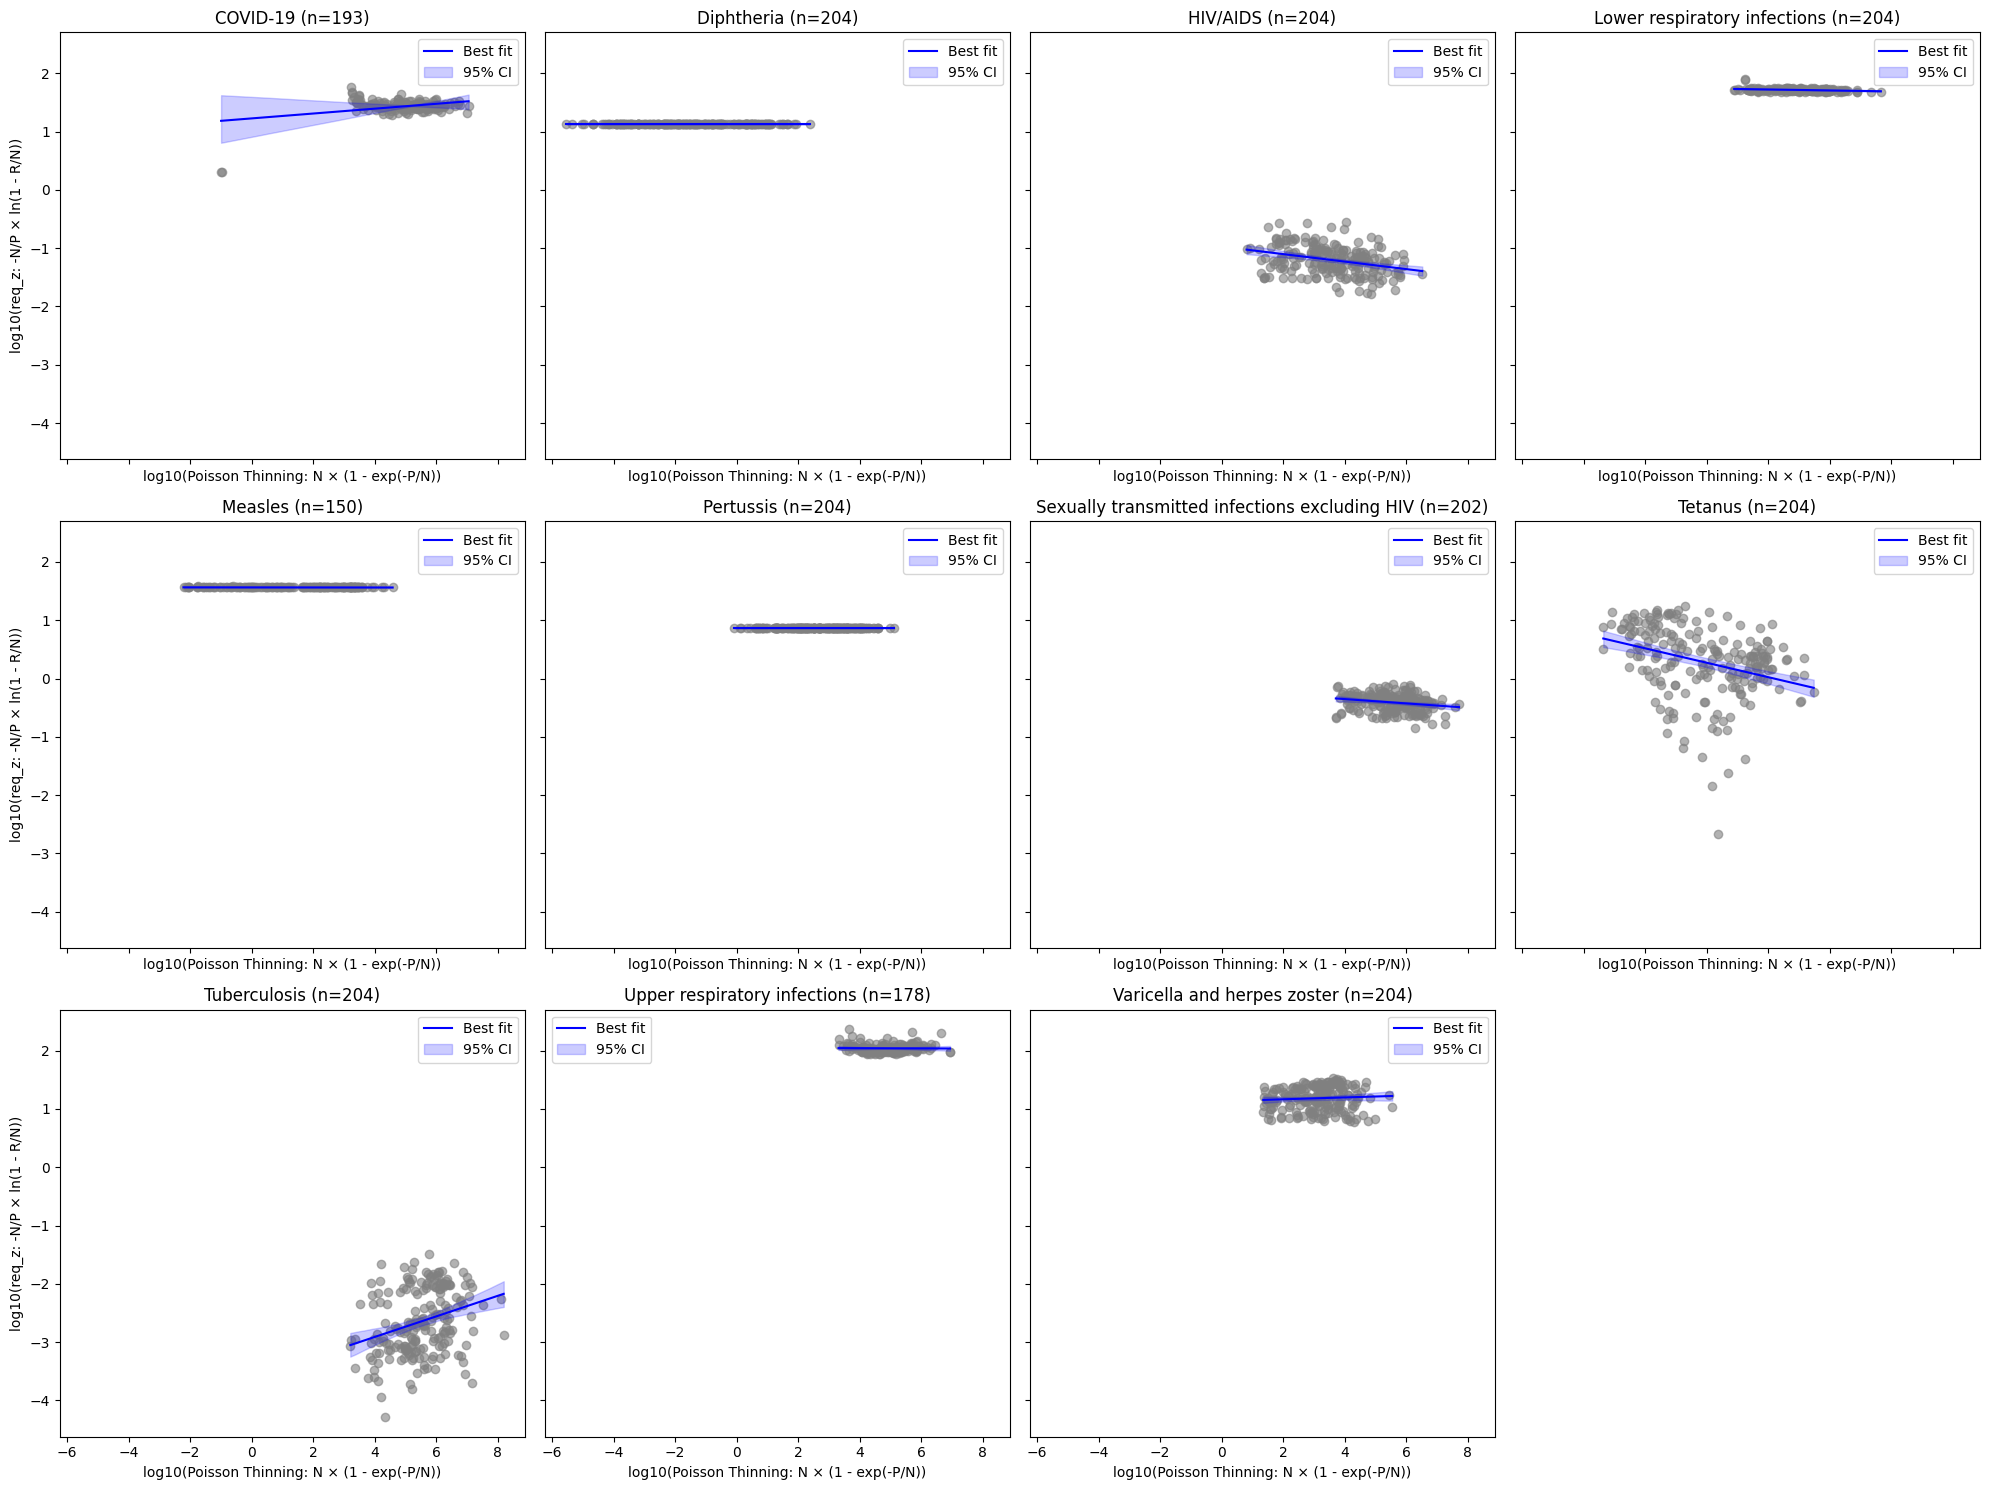

In [ ]:
# Cell 17: Faceted log10(pt) vs log10(req_z) by cause - PORTED FROM VIRAL

# Using valid_z filtering from Cell 14
valid_z = (
    (~np.isnan(pt_z := N_z * (1 - np.exp(-P_z / N_z)))) &
    (~np.isnan(req_z)) &
    (pt_z > 0) & (req_z > 0) &
    np.isfinite(pt_z) & np.isfinite(req_z)
)

# Get cause labels for z-valid points
cause_z_full = np.array(pivoted['epi_cause_name'])[mask_z.values]
cause_z = cause_z_full[valid_z]
x_z_panel = np.log10(pt_z[valid_z])
y_z_panel = np.log10(req_z[valid_z])

cause_list_z = np.unique(cause_z)
ncol = 4
nrow = int(np.ceil(len(cause_list_z) / ncol))
n_bootstrap = 1000

fig, axes = plt.subplots(nrow, ncol, figsize=(5*ncol, 5*nrow), sharex=True, sharey=True)
axes = axes.flatten()

print('log10(req_z) Bootstrapped Slopes & R2 (Poisson thinning by cause):')
for i, illness in enumerate(cause_list_z):
    idx = (cause_z == illness)
    ax = axes[i]
    x_cause = x_z_panel[idx]
    y_cause = y_z_panel[idx]
    ax.scatter(x_cause, y_cause, color='grey', alpha=0.6)
    ax.set_title(f"{illness} (n={len(x_cause)})")
    ax.set_xlabel('log10(Poisson Thinning: N × (1 - exp(-P/N))')
    if i % ncol == 0:
        ax.set_ylabel('log10(req_z: -N/P × ln(1 - R/N))')

    if len(x_cause) >= 5:
        slopes = []
        intercepts = []
        r2s = []
        for _ in range(n_bootstrap):
            boot_idx = np.random.randint(0, len(x_cause), len(x_cause))
            x_boot = x_cause[boot_idx]
            y_boot = y_cause[boot_idx]
            s, b = np.polyfit(x_boot, y_boot, 1)
            slopes.append(s)
            intercepts.append(b)
            y_pred = s * x_boot + b
            ss_res = np.sum((y_boot - y_pred)**2)
            ss_tot = np.sum((y_boot - np.mean(y_boot))**2)
            r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
            r2s.append(r2)
        mean_slope = np.mean(slopes)
        mean_intercept = np.mean(intercepts)
        slope_lo, slope_hi = np.percentile(slopes, [2.5, 97.5])
        r2_mean = np.nanmean(r2s)
        x_pred = np.linspace(x_cause.min(), x_cause.max(), 100)
        y_pred_mat = np.array([s * x_pred + b for s, b in zip(slopes, intercepts)])
        y_low, y_high = np.percentile(y_pred_mat, [2.5, 97.5], axis=0)
        ax.plot(x_pred, mean_slope * x_pred + mean_intercept, color='blue', label='Best fit')
        ax.fill_between(x_pred, y_low, y_high, color='blue', alpha=0.2, label='95% CI')
        ax.legend()
        print(f"{illness:20}: slope={mean_slope:.3f} [{slope_lo:.3f},{slope_hi:.3f}], "
              f"R2={r2_mean:.3f}, n={len(x_cause)}")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('/content/drive/My Drive/Hopeful Monsters/Projects/Mass Action 2025/Datasets/Epidemiology/logz_cause_panel_pt.pdf', bbox_inches='tight')
plt.show()